In [1]:
!unzip /content/archive.zip

Archive:  /content/archive.zip
  inflating: Game_of_Thrones.csv     


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.neighbors import NearestNeighbors

In [3]:
df = pd.read_csv("/content/Game_of_Thrones.csv")

In [4]:
df

,Season,No. of Episode (Season),No. of Episode (Overall),Title of the Episode,Running Time (Minutes),Directed by,Written by,Original Air Date,U.S. Viewers (Millions),Music by,Cinematography by,Editing by,IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings,Ordered,Filming Duration,Novel(s) Adapted,Synopsis
0,1,1,1,Winter Is Coming,61,Tim Van Patten,"David Benioff, D. B. Weiss",17-Apr-2011,2.22,Ramin Djawadi,Alik Sakharov,Oral Norrie Ottey,8.9,100,9.1,"March 2, 2010",Second half of 2010,A Game of Thrones,"North of the Seven Kingdoms of Westeros, Night..."
1,1,2,2,The Kingsroad,55,Tim Van Patten,"David Benioff, D. B. Weiss",24-Apr-2011,2.20,Ramin Djawadi,Alik Sakharov,Oral Norrie Ottey,8.6,100,8.9,"March 2, 2010",Second half of 2010,A Game of Thrones,"Ned, the new Hand of the King, travels to King..."
2,1,3,3,Lord Snow,57,Brian Kirk,"David Benioff, D. B. Weiss",1-May-2011,2.44,Ramin Djawadi,Marco Pontecorvo,Frances Parker,8.5,81,8.7,"March 2, 2010",Second half of 2010,A Game of Thrones,Ned attends the King's Small Council and learn...
3,1,4,4,"Cripples, Bastards, and Broken Things",55,Brian Kirk,Bryan Cogman,8-May-2011,2.45,Ramin Djawadi,Marco Pontecorvo,Frances Parker,8.6,100,9.1,"March 2, 2010",Second half of 2010,A Game of Thrones,"While returning to King's Landing, Tyrion stop..."
4,1,5,5,The Wolf and the Lion,54,Brian Kirk,"David Benioff, D. B. Weiss",15-May-2011,2.58,Ramin Djawadi,Marco Pontecorvo,Frances Parker,9.0,95,9.0,"March 2, 2010",Second half of 2010,A Game of Thrones,"King Robert's eunuch spy, Varys, has uncovered..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,8,2,69,A Knight of the Seven Kingdoms,57,David Nutter,Bryan Cogman,21-Apr-2019,10.29,Ramin Djawadi,David Franco,Crispin Green,7.9,87,5.9,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,Jaime reveals Cersei's deception to the Targar...
69,8,3,70,The Long Night,81,Miguel Sapochnik,"David Benioff, D. B. Weiss",28-Apr-2019,12.02,Ramin Djawadi,Fabian Wagner,Tim Porter,7.5,74,4.2,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,The living meet the Army of the Dead outside W...
70,8,4,71,The Last of the Starks,77,David Nutter,"David Benioff, D. B. Weiss",5-May-2019,11.80,Ramin Djawadi,David Franco,Katie Weiland,5.5,58,2.9,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,"The survivors mourn, burn the dead and then ce..."
71,8,5,72,The Bells,77,Miguel Sapochnik,"David Benioff, D. B. Weiss",12-May-2019,12.48,Ramin Djawadi,Fabian Wagner,Tim Porter,6.0,49,3.4,"July 30, 2016",October 2017 – July 2018,Outline from A Dream of Spring and original co...,Varys urges Jon to advance his claim to the th...


In [7]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Season                               73 non-null     int64  
 1   No. of Episode (Season)              73 non-null     int64  
 2   No. of Episode (Overall)             73 non-null     int64  
 3   Title of the Episode                 73 non-null     object 
 4   Running Time (Minutes)               73 non-null     int64  
 5   Directed by                          73 non-null     object 
 6   Written by                           73 non-null     object 
 7   Original Air Date                    73 non-null     object 
 8   U.S. Viewers (Millions)              73 non-null     float64
 9   Music by                             73 non-null     object 
 10  Cinematography by                    73 non-null     object 
 11  Editing by                        

In [8]:
df.describe()


,Season,No. of Episode (Season),No. of Episode (Overall),Running Time (Minutes),U.S. Viewers (Millions),IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,4.205479,5.191781,37.000000,56.945205,6.447808,8.741096,91.972603,7.817808
std,2.191897,2.821827,21.217131,7.185809,2.827372,0.932565,11.499967,1.684186
min,1.000000,1.000000,1.000000,49.000000,2.200000,4.000000,47.000000,2.600000
25%,2.000000,3.000000,19.000000,52.000000,3.900000,8.500000,89.000000,6.500000
50%,4.000000,5.000000,37.000000,55.000000,6.640000,8.800000,96.000000,8.500000
75%,6.000000,7.000000,55.000000,58.000000,7.820000,9.300000,100.000000,9.100000
max,8.000000,10.000000,73.000000,81.000000,13.610000,9.900000,100.000000,9.700000


In [9]:

df.isnull().sum()


,0
Season,0
No. of Episode (Season),0
No. of Episode (Overall),0
Title of the Episode,0
Running Time (Minutes),0
Directed by,0
Written by,0
Original Air Date,0
U.S. Viewers (Millions),0
Music by,0


In [10]:
df.shape

(73, 19)

In [12]:
df.head(1)

,Season,No. of Episode (Season),No. of Episode (Overall),Title of the Episode,Running Time (Minutes),Directed by,Written by,Original Air Date,U.S. Viewers (Millions),Music by,Cinematography by,Editing by,IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings,Ordered,Filming Duration,Novel(s) Adapted,Synopsis
0,1,1,1,Winter Is Coming,61,Tim Van Patten,"David Benioff, D. B. Weiss",17-Apr-2011,2.22,Ramin Djawadi,Alik Sakharov,Oral Norrie Ottey,8.9,100,9.1,"March 2, 2010",Second half of 2010,A Game of Thrones,"North of the Seven Kingdoms of Westeros, Night..."


In [13]:
df["Original Air Date"] = pd.to_datetime(df["Original Air Date"])

In [14]:
df["Year"] = df["Original Air Date"].dt.year
df["Month"] = df["Original Air Date"].dt.month

In [15]:
episode_names = df["Title of the Episode"]

df = df.drop(columns=[
    "Title of the Episode",
    "Synopsis",
    "Original Air Date"
])

In [16]:
categorical = df.select_dtypes(include="object").columns

categorical

Index(['Directed by', 'Written by', 'Music by', 'Cinematography by',
       'Editing by', 'Ordered', 'Filming Duration', 'Novel(s) Adapted'],
      dtype='object')

In [17]:
df.head(1)

,Season,No. of Episode (Season),No. of Episode (Overall),Running Time (Minutes),Directed by,Written by,U.S. Viewers (Millions),Music by,Cinematography by,Editing by,IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings,Ordered,Filming Duration,Novel(s) Adapted,Year,Month
0,1,1,1,61,Tim Van Patten,"David Benioff, D. B. Weiss",2.22,Ramin Djawadi,Alik Sakharov,Oral Norrie Ottey,8.9,100,9.1,"March 2, 2010",Second half of 2010,A Game of Thrones,2011,4


In [18]:
df = pd.get_dummies(df, columns=categorical)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [20]:
df.head(1)

,Season,No. of Episode (Season),No. of Episode (Overall),Running Time (Minutes),U.S. Viewers (Millions),IMDb Rating,Rotten Tomatoes Rating (Percentage),Metacritic Ratings,Year,Month,...,Filming Duration_July–November 2013,Filming Duration_October 2017 – July 2018,Filming Duration_Second half of 2010,Filming Duration_Second half of 2011,Novel(s) Adapted_A Clash of Kings,"Novel(s) Adapted_A Feast for Crows, A Dance with Dragons and original content",Novel(s) Adapted_A Game of Thrones,Novel(s) Adapted_A Storm of Swords,Novel(s) Adapted_Outline from A Dream of Spring and original content,Novel(s) Adapted_Outline from The Winds of Winter and original content
0,1,1,1,61,2.22,8.9,100,9.1,2011,4,...,False,False,True,False,False,False,True,False,False,False


In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print(pca_data.shape)

(73, 2)


In [28]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Episode"] = episode_names

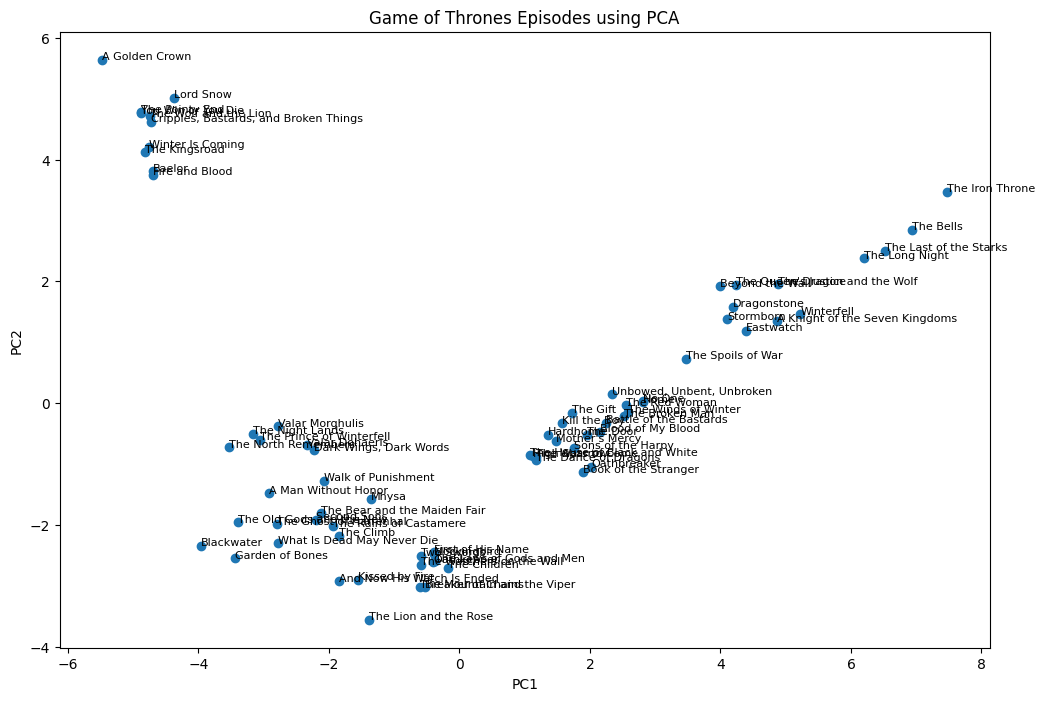

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"]
)

for i, txt in enumerate(pca_df["Episode"]):
    plt.text(
        pca_df["PC1"][i],
        pca_df["PC2"][i],
        txt,
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Game of Thrones Episodes using PCA")

plt.show()

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(pca_data)

In [31]:
import numpy as np

def recommend_episode(name):

    idx = episode_names[episode_names == name].index[0]

    sim = similarity[idx]

    indices = np.argsort(sim)[::-1][1:6]

    print("Similar Episodes:\n")

    for i in indices:
        print(episode_names.iloc[i])

In [32]:
recommend_episode("Winter Is Coming")

Similar Episodes:

The Kingsroad
Baelor
Fire and Blood
You Win or You Die
The Pointy End


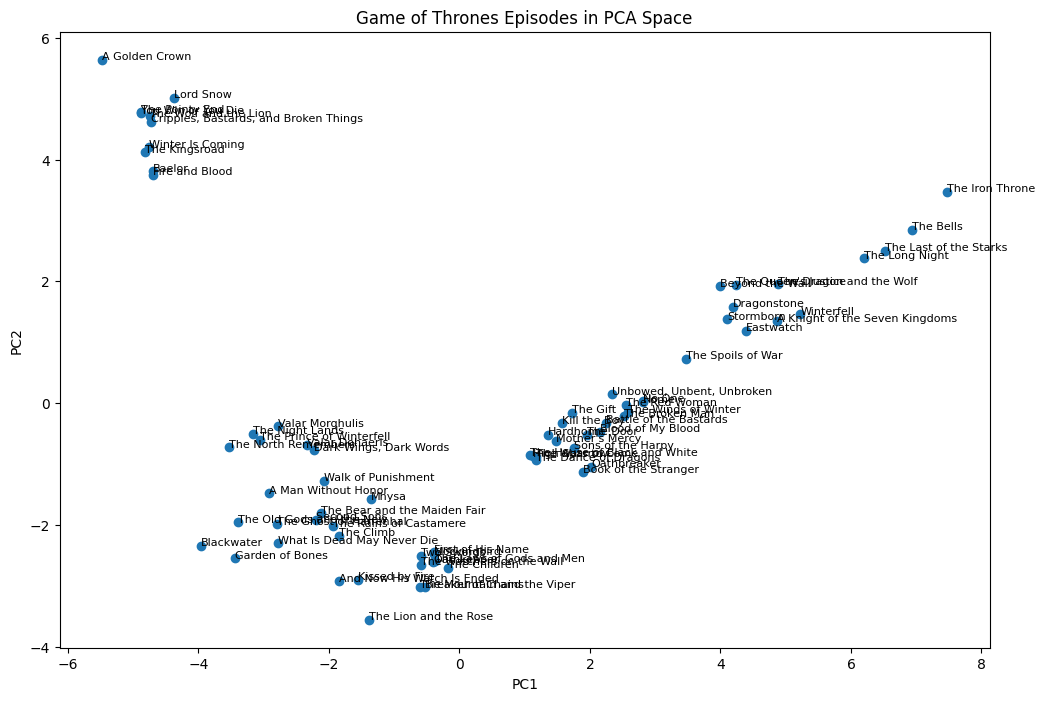

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.scatter(pca_data[:,0], pca_data[:,1])

for i, txt in enumerate(episode_names):
    plt.annotate(txt, (pca_data[i,0], pca_data[i,1]), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Game of Thrones Episodes in PCA Space")

plt.show()